# Sentiment Analysis using Machine Learning

## VortexTech AI & ML Internship-Week 4

This project focuses on building a Natural Language Processing (NLP) model to classify movie reviews as **Positive** or **Negative**.

The project uses the **IMDB 50K Movie Reviews dataset** and follows a complete machine learning pipeline including data exploration, text preprocessing, TF-IDF feature extraction, model training, evaluation, and prediction on new reviews.

### Objectives

* Analyze and preprocess text data.
* Convert text into numerical features using TF-IDF.
* Train a Logistic Regression classification model.
* Evaluate the model using accuracy, F1-score, and a confusion matrix.
* Test the trained model on new custom sentences.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
import os
print("Current folder:")
print(os.getcwd())
print("\nFiles and folders:")
print(os.listdir())

Current folder:
C:\Users\Noman Traders\Desktop\VortexTech-AIML-Week4

Files and folders:
['.ipynb_checkpoints', 'venv', 'Week4_Sentiment_Analysis.ipynb']


In [5]:
df = pd.read_csv("IMDB Dataset.csv")
print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
print("Column names:")
print(df.columns.tolist())
print("\nDataset information:")
df.info()
print("\nMissing values:")
print(df.isnull().sum())
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

Column names:
['review', 'sentiment']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Missing values:
review       0
sentiment    0
dtype: int64

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


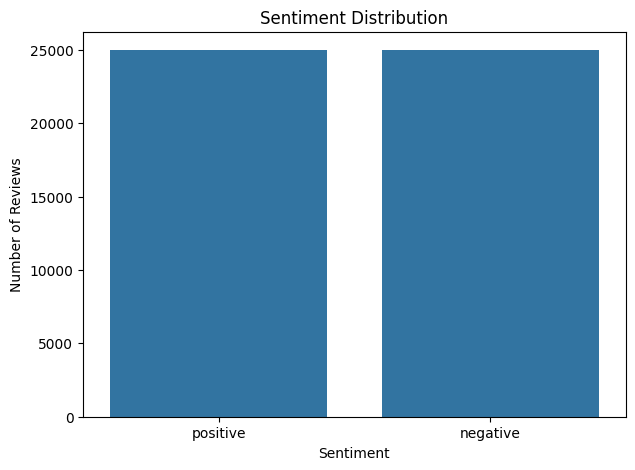

In [7]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="sentiment")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [8]:
df["review_length"] = df["review"].apply(len)
print("Review length statistics:")
print(df["review_length"].describe())

Review length statistics:
count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64


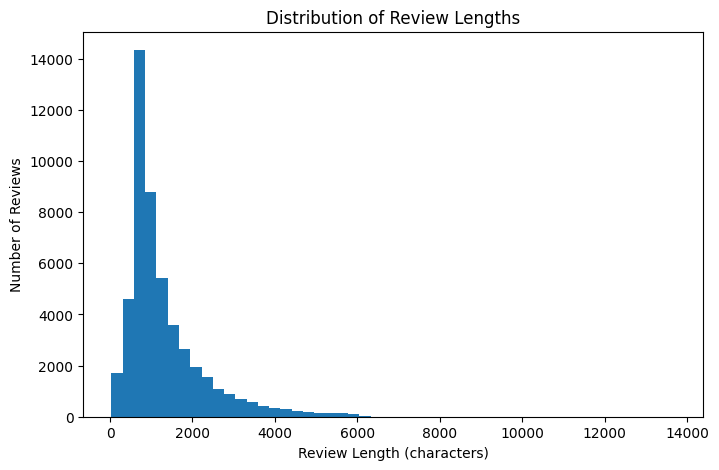

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df["review_length"], bins=50)
plt.title("Distribution of Review Lengths")
plt.xlabel("Review Length (characters)")
plt.ylabel("Number of Reviews")
plt.show()

In [13]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to C:\Users\Noman
[nltk_data]     Traders\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Noman
[nltk_data]     Traders\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Noman
[nltk_data]     Traders\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [14]:
import re
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    # Keep only letters and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    # Split into words
    words = text.split()
    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    # Join words back together
    return " ".join(words)
print("Text cleaning function created successfully!")

Text cleaning function created successfully!


In [15]:
sample_review = df["review"].iloc[0]
print("Original Review:")
print(sample_review)
print("\n" + "=" * 80 + "\n")
print("Cleaned Review:")
print(clean_text(sample_review))

Original Review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

In [18]:
print("Cleaning all reviews...")
df["cleaned_review"] = df["review"].apply(clean_text)
print("All reviews cleaned successfully!")
df[["review", "cleaned_review", "sentiment"]].head()

Cleaning all reviews...
All reviews cleaned successfully!


,review,cleaned_review,sentiment
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...,positive
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,positive
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...,positive


In [19]:
df["sentiment_label"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1 })
print("Sentiment labels converted successfully!")
print(df[["sentiment", "sentiment_label"]].head())
print("\nLabel distribution:")
print(df["sentiment_label"].value_counts())

Sentiment labels converted successfully!
  sentiment  sentiment_label
0  positive                1
1  positive                1
2  positive                1
3  negative                0
4  positive                1

Label distribution:
sentiment_label
1    25000
0    25000
Name: count, dtype: int64


In [20]:
X = df["cleaned_review"]
y = df["sentiment_label"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y  )
print("Data split successfully!")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Data split successfully!
Training samples: 40000
Testing samples: 10000


In [21]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2) )
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("TF-IDF vectorization completed!")
print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)

TF-IDF vectorization completed!
Training data shape: (40000, 5000)
Testing data shape: (10000, 5000)


In [22]:
model = LogisticRegression(max_iter=1000)
print("Training Logistic Regression model...")
model.fit(X_train_tfidf, y_train)
print("Model trained successfully!")

Training Logistic Regression model...
Model trained successfully!


In [23]:
y_pred = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

Model Accuracy: 0.8919
Model Accuracy (%): 89.19


In [24]:
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"]  ))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      5000
    Positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



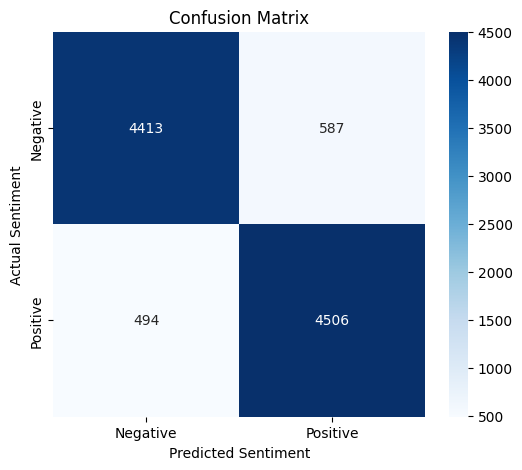

In [25]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"] )
plt.title("Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.show()

In [26]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
comparison["Actual"] = comparison["Actual"].map({
    0: "Negative",
    1: "Positive"
})
comparison["Predicted"] = comparison["Predicted"].map({
    0: "Negative",
    1: "Positive"
})
print("Sample Predictions:")
print(comparison.head(10))

Sample Predictions:
     Actual Predicted
0  Negative  Negative
1  Negative  Negative
2  Positive  Positive
3  Negative  Negative
4  Negative  Negative
5  Negative  Negative
6  Negative  Negative
7  Negative  Negative
8  Negative  Negative
9  Negative  Negative


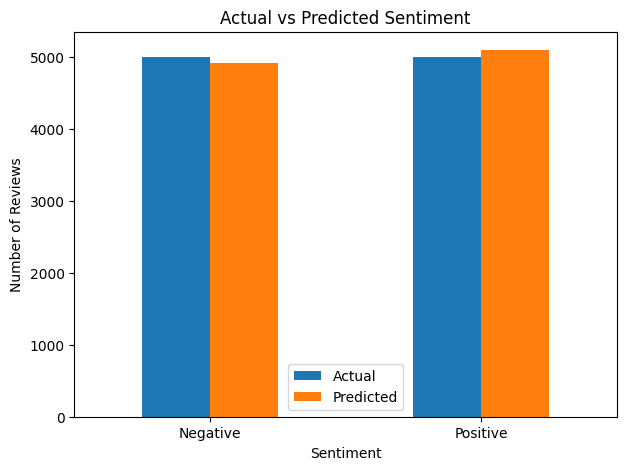

In [27]:
comparison_counts = pd.DataFrame({
    "Actual": y_test.map({0: "Negative", 1: "Positive"}).value_counts(),
    "Predicted": pd.Series(y_pred).map({0: "Negative", 1: "Positive"}).value_counts()
})
comparison_counts.plot(
    kind="bar",
    figsize=(7, 5)
)
plt.title("Actual vs Predicted Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

In [28]:
new_review = [
    "This movie was absolutely amazing! The story was great and the acting was excellent."
]
new_review_cleaned = [clean_text(review) for review in new_review]
new_review_tfidf = tfidf.transform(new_review_cleaned)
prediction = model.predict(new_review_tfidf)[0]
if prediction == 1:
    print("Predicted Sentiment: Positive")
else:
    print("Predicted Sentiment: Negative")

Predicted Sentiment: Positive


In [29]:
print("=" * 50)
print("SENTIMENT ANALYSIS - FINAL RESULTS")
print("=" * 50)

print(f"Dataset Size: {len(df)} reviews")
print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")
print(f"TF-IDF Features: {X_train_tfidf.shape[1]}")
print(f"Model: Logistic Regression")
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Performance:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"]
))

SENTIMENT ANALYSIS - FINAL RESULTS
Dataset Size: 50000 reviews
Training Samples: 40000
Testing Samples: 10000
TF-IDF Features: 5000
Model: Logistic Regression
Accuracy: 89.19%

Classification Performance:
              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      5000
    Positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [30]:
custom_reviews = [
    "This movie was absolutely amazing! The story was great and the acting was excellent.",
    "The movie was boring, poorly written, and a complete waste of time.",
    "I really enjoyed this film because the characters were interesting and the story was exciting."
]
custom_reviews_cleaned = [clean_text(review) for review in custom_reviews]
custom_reviews_tfidf = tfidf.transform(custom_reviews_cleaned)
predictions = model.predict(custom_reviews_tfidf)
print("Custom Review Predictions:")
print("=" * 50)
for review, prediction in zip(custom_reviews, predictions):
    sentiment = "Positive" if prediction == 1 else "Negative"
    print("\nReview:", review)
    print("Predicted Sentiment:", sentiment)

Custom Review Predictions:

Review: This movie was absolutely amazing! The story was great and the acting was excellent.
Predicted Sentiment: Positive

Review: The movie was boring, poorly written, and a complete waste of time.
Predicted Sentiment: Negative

Review: I really enjoyed this film because the characters were interesting and the story was exciting.
Predicted Sentiment: Positive


## Conclusion

This project developed a sentiment analysis model using the IMDB 50K Movie Reviews dataset.

The reviews were cleaned and preprocessed by converting text to lowercase, removing HTML tags and special characters, removing stopwords, and applying lemmatization. The cleaned text was then converted into numerical features using TF-IDF with 5,000 features.

A Logistic Regression classifier was trained on 40,000 reviews and evaluated on 10,000 test reviews.

### Final Results

* Dataset Size: 50,000 reviews
* Training Samples: 40,000
* Testing Samples: 10,000
* TF-IDF Features: 5,000
* Model: Logistic Regression
* Accuracy: 89.19%
* Negative F1-Score: 0.89
* Positive F1-Score: 0.89

### Custom Predictions

The trained model was tested on three new example sentences:

1. "This movie was absolutely amazing! The story was great and the acting was excellent." → **Positive**
2. "The movie was boring, poorly written, and a complete waste of time." → **Negative**
3. "I really enjoyed this film because the characters were interesting and the story was exciting." → **Positive**

### Limitation

One limitation of the model is that it may struggle with sarcasm, complex context, or reviews where positive and negative opinions are mixed. The model mainly learns patterns from the words in the training data and may not fully understand the deeper meaning of a sentence.

Overall, this project demonstrates a complete Natural Language Processing and Machine Learning pipeline, from raw text preprocessing and TF-IDF feature extraction to model training, evaluation, and sentiment prediction.
